In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [31]:
dataset=pd.read_csv('Position_Salaries.csv')
print(dataset)

            Position  Level   Salary
0   Business Analyst      1    45000
1  Junior Consultant      2    50000
2  Senior Consultant      3    60000
3            Manager      4    80000
4    Country Manager      5   110000
5     Region Manager      6   150000
6            Partner      7   200000
7     Senior Partner      8   300000
8            C-level      9   500000
9                CEO     10  1000000


In [32]:
x=dataset.iloc[:, 1:2].values # Features
y=dataset.iloc[:,2].values # Target
print(x)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]


In [33]:
print(y)

[  45000   50000   60000   80000  110000  150000  200000  300000  500000
 1000000]


In [34]:
y=y.reshape(-1,1)
print(y)

[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


In [35]:
from sklearn.preprocessing import StandardScaler
stds_x=StandardScaler()
stds_y=StandardScaler()
x=stds_x.fit_transform(x)
y=stds_y.fit_transform(y)

In [36]:
print("Scaled X : \n",x)
print("Scaled Y : \n",y)

Scaled X : 
 [[-1.5666989 ]
 [-1.21854359]
 [-0.87038828]
 [-0.52223297]
 [-0.17407766]
 [ 0.17407766]
 [ 0.52223297]
 [ 0.87038828]
 [ 1.21854359]
 [ 1.5666989 ]]
Scaled Y : 
 [[-0.72004253]
 [-0.70243757]
 [-0.66722767]
 [-0.59680786]
 [-0.49117815]
 [-0.35033854]
 [-0.17428902]
 [ 0.17781001]
 [ 0.88200808]
 [ 2.64250325]]


Text(0.5, 1.0, 'Scatter Plot')

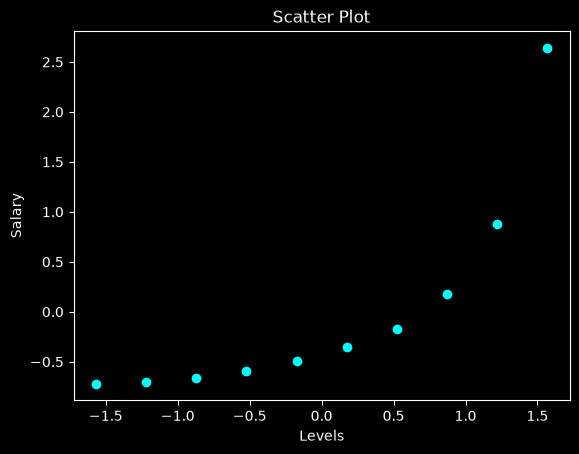

In [37]:
plt.style.use("dark_background")
plt.scatter(x,y,c='cyan')
plt.xlabel("Levels")
plt.ylabel("Salary")
plt.title("Scatter Plot")

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(len(x_train))
print(len(x_test))

8
2


In [39]:
from sklearn.svm import SVR

regressor=SVR(kernel='rbf')
regressor.fit(x_train,y_train)

c:\Users\LENOVO\anaconda\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [ ]:
A=regressor.predict(x_test)
print(A)

[ 0.65639086 -0.63286185]
[[435922.22629664]
 [ 69760.27239844]]


In [43]:
A_pred=stds_y.inverse_transform(A.reshape(-1,1))
print(A_pred)

[[435922.22629664]
 [ 69760.27239844]]


In [45]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error)
print("MAE :",mean_absolute_error(y_test,A))
print("MSE :",mean_squared_error(y_test,A))

MAE : 0.1475964753571336
MSE : 0.027871956510258034


Text(0, 0.5, 'Salary')

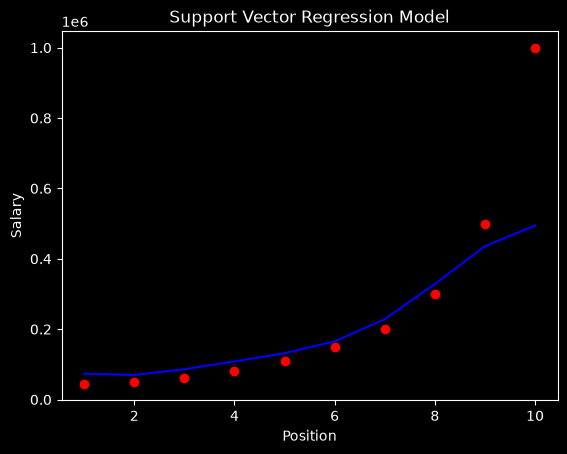

In [52]:
plt.scatter(stds_x.inverse_transform(x),stds_y.inverse_transform(y),c='r')
plt.plot(stds_x.inverse_transform(x),stds_y.inverse_transform(regressor.predict(x).reshape(-1,1)),c='b')
plt.title("Support Vector Regression Model")
plt.xlabel("Position")
plt.ylabel("Salary")